# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="/Users/muhammadanas/Desktop/DATA-3402 Python 2/Lab7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

LinearDiscriminantAnalysis()

We can plot the output, comparing signal and background:

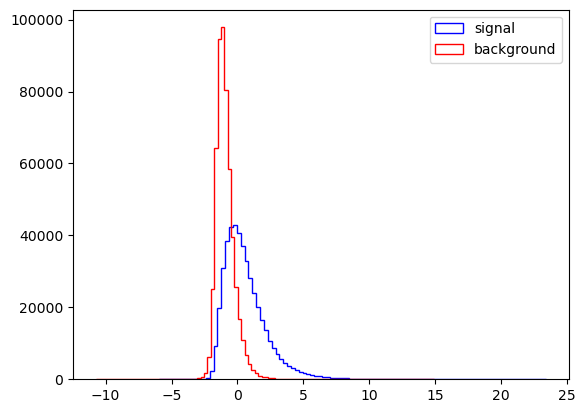

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

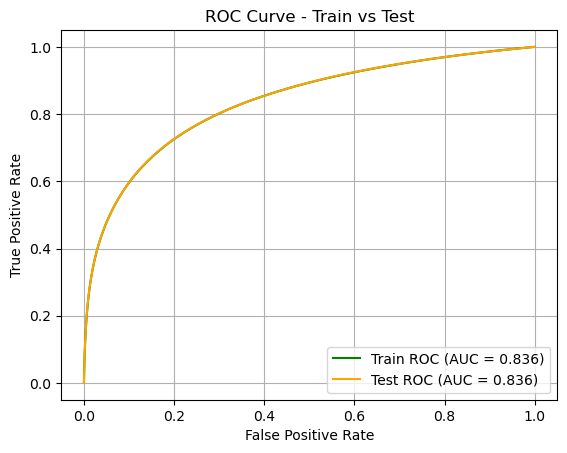

In [7]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get decision function scores
y_train_scores = Fisher.decision_function(X_Train)
y_test_scores = Fisher.decision_function(X_Test)

# Compute ROC curves
fpr_train, tpr_train, _ = roc_curve(y_Train, y_train_scores)
fpr_test, tpr_test, _ = roc_curve(y_Test, y_test_scores)

# Compute AUCs
auc_train = auc(fpr_train, tpr_train)
auc_test = auc(fpr_test, tpr_test)

# Plot
plt.figure()
plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC = {auc_train:.3f})", color="green")
plt.plot(fpr_test, tpr_test, label=f"Test ROC (AUC = {auc_test:.3f})", color="orange")

## Labeling the graph
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Train vs Test")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 


In [8]:
## Making the same model on Raw and Features

Raw_Fisher = DA.LinearDiscriminantAnalysis()
Feature_Fisher = DA.LinearDiscriminantAnalysis()

In [9]:
## Training and Testing for Raw and Features

X_Raw_Train = Train_Sample[VarNames[1:9]]
X_Feature_Train = Train_Sample[VarNames[9:]]

X_Raw_Test = Test_Sample[VarNames[1:9]]
X_Feature_Test = Test_Sample[VarNames[9:]]

In [10]:
## Fitting the model

Raw_Fisher.fit(X_Raw_Train, y_Train)
Feature_Fisher.fit(X_Feature_Train, y_Train)

LinearDiscriminantAnalysis()

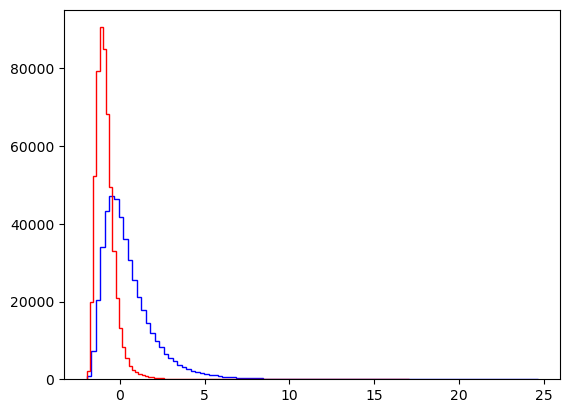

In [11]:
## Plotting the Raw (Test signal, Test background)

plt.hist(Raw_Fisher.decision_function(Test_sig[VarNames[1:9]]), bins= 100, histtype= 'step', color= 'blue', label= 'signal', stacked= True)
plt.hist(Raw_Fisher.decision_function(Test_bkg[VarNames[1:9]]), bins= 100, histtype= 'step', color= 'red', label= 'background', stacked= True)
plt.show()

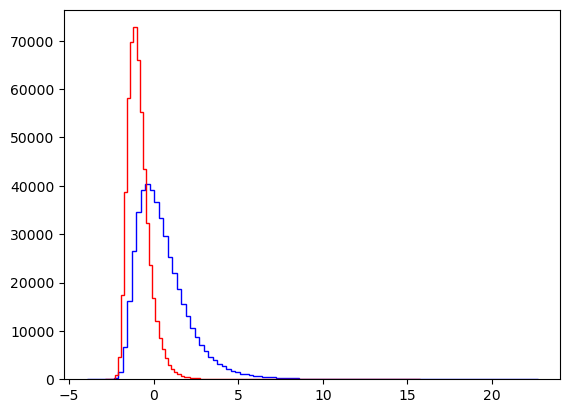

In [12]:
## Plotting the Features (Test signal, Test background)

plt.hist(Feature_Fisher.decision_function(Test_sig[VarNames[9:]]), bins= 100, histtype= 'step', color= 'blue', label= 'signal', stacked= True)
plt.hist(Feature_Fisher.decision_function(Test_bkg[VarNames[9:]]), bins= 100, histtype= 'step', color= 'red', label= 'background', stacked= True)
plt.show()

In [13]:
## Converting them to array

raw_array = Raw_Fisher.decision_function(X_Raw_Test)
feature_array = Feature_Fisher.decision_function(X_Feature_Test)

In [14]:
## Finding the max for Raw

raw_array.max()

24.639803910871223

In [15]:
## Finding the max for Feature

feature_array.max()

22.702341352495967

In [16]:
## Sorting the Raw arrays

sortA = np.sort(raw_array)
sortA.size

1000000

In [17]:
## Sorting the Features arrays

sortB = np.sort(feature_array)
sortB.size

1000000

In [18]:
## Comparing the Raw and Features

comparison_AB = list(zip(sortA, sortB))
comparison_AB

[(-1.9507361227672493, -3.970067281359565),
 (-1.9433167630597015, -3.6267815064237894),
 (-1.935378970965668, -3.273778918368152),
 (-1.935191511346453, -3.071168060774485),
 (-1.9317065567797205, -3.0176555735502637),
 (-1.9312454969321329, -2.939889421388791),
 (-1.9284910393053305, -2.926958726500414),
 (-1.9251896170396183, -2.882919071751322),
 (-1.9240526311612254, -2.880126323597307),
 (-1.9229954418050834, -2.866808316644765),
 (-1.9218605764647132, -2.8438722659463322),
 (-1.9205417420920707, -2.8422511000265467),
 (-1.9187705098331918, -2.84131719668186),
 (-1.9187624466342075, -2.8398260546854437),
 (-1.9186149709326261, -2.834089698531421),
 (-1.9185262113482469, -2.75531851168328),
 (-1.9181358892634155, -2.748908803481423),
 (-1.9180365758614897, -2.726194244518913),
 (-1.9154033267154165, -2.7089141095992795),
 (-1.9148740510822722, -2.705464373079735),
 (-1.914560384605684, -2.7028935883689593),
 (-1.9138550551502782, -2.701868201591145),
 (-1.9126939992096776, -2.6993

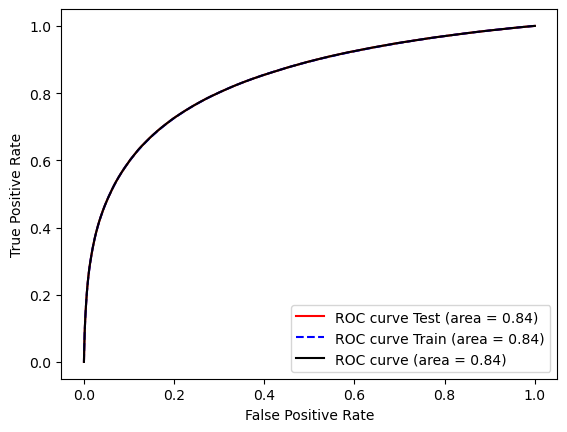

In [19]:
## calculating fpr and tpr for regular, Feature and raw using roc_curve

fpr_raw, tpr_raw, _ = roc_curve(y_Test, Raw_Fisher.decision_function(X_Raw_Test))
fpr_feat, tpr_feat, _ = roc_curve(y_Test, Feature_Fisher.decision_function(X_Feature_Test))
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))


## calculating fpr and tpr for regular, Feature and raw using auc_curve
roc_auc_Test = auc(fpr_test, tpr_test)
roc_auc_Train = auc(fpr_train, tpr_train)
roc_auc = auc(fpr, tpr)

## Plotting the above ROC test and train curves
plt.plot(fpr_test, tpr_test, color= 'red', label= 'ROC curve Test (area = %0.2f)' % roc_auc_Test)
plt.plot(fpr_train, tpr_train, color= 'blue', linestyle= 'dashed', label= 'ROC curve Train (area = %0.2f)' % roc_auc_Train)
plt.plot(fpr, tpr, color= 'black', label= 'ROC curve (area = %0.2f)' % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc= "lower right")
plt.show()


### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 5.

In [20]:
## Using Linear Regression as out first model

from sklearn import linear_model
LineReg = linear_model.LinearRegression()
LineReg.fit(X_Train, y_Train)

LinearRegression()

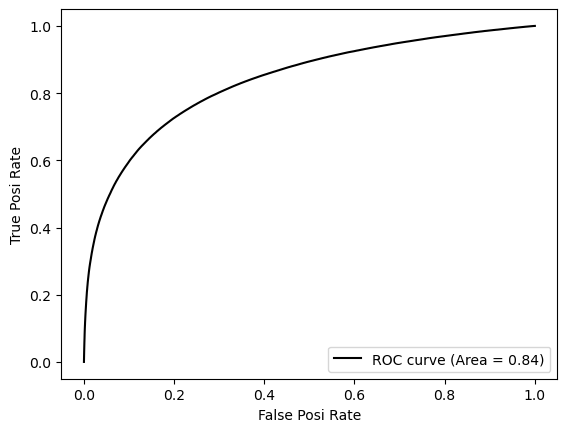

In [21]:
## Calculating and plotting roc curve using linear regrssion model

fpr, tpr, _, = roc_curve(y_Test, LineReg.predict(X_Test))
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color= 'black', label= 'ROC curve (Area = %0.2f)' % roc_auc)
plt.xlabel('False Posi Rate')
plt.ylabel('True Posi Rate')
plt.legend(loc= 'lower right')
plt.show()

In [22]:
## Using Gaussian as our second model

from sklearn.naive_bayes import GaussianNB
gnb = GaussianNB()
gnb.fit(X_Train, y_Train)

GaussianNB()

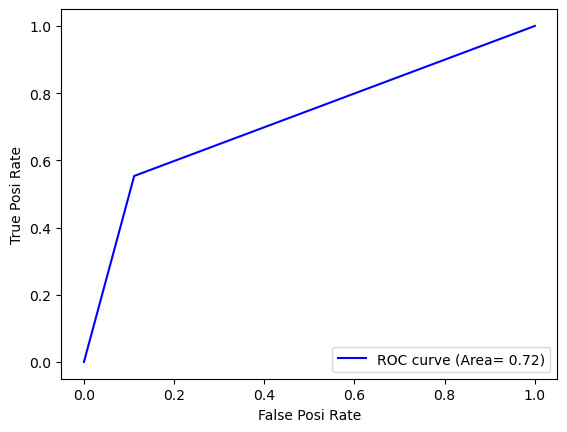

In [23]:
## Calculating and plotting roc curve using gaussian model

fpr, tpr, _ = roc_curve(y_Test, gnb.predict(X_Test))
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color= 'blue', label= 'ROC curve (Area= %.2f)' % roc_auc)
plt.xlabel('False Posi Rate')
plt.ylabel('True Posi Rate')
plt.legend(loc= 'lower right')
plt.show()


In [24]:
## Using Decision Tree as out third model

from sklearn import tree
T = tree.DecisionTreeClassifier()
T = T.fit(X_Train, y_Train)

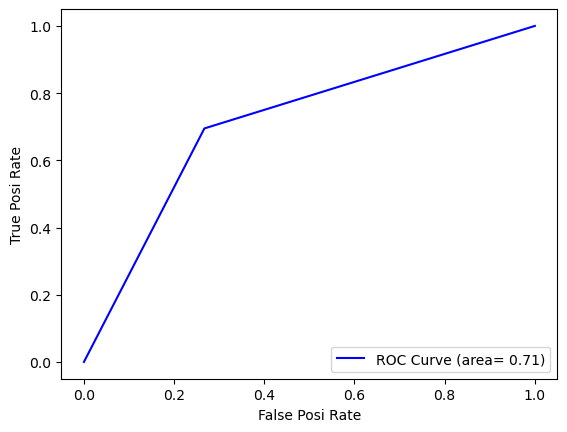

In [25]:
## Calculating and plotting roc curve using decision tree model

fpr, tpr, _ = roc_curve(y_Test, T.predict(X_Test))
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color= 'blue', label= 'ROC Curve (area= %.2f)' % roc_auc)
plt.xlabel('False Posi Rate')
plt.ylabel('True Posi Rate')
plt.legend(loc= 'lower right')
plt.show()

### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

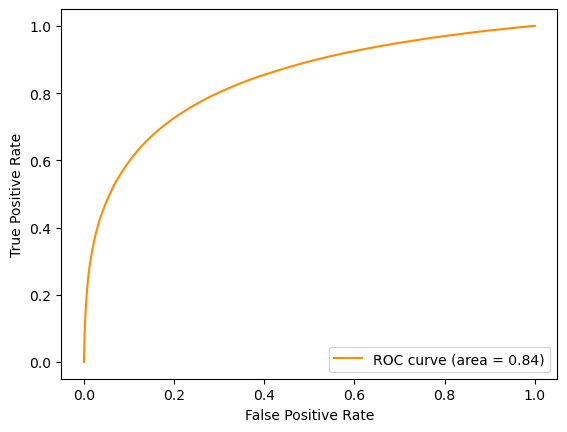

In [26]:
## Caluclating and plotting ROC curve

from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [27]:
## Writing a fucntion to calcualte precision, recall, accuracy, f1_score of each model we used above.

from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score

def evaluate_model(model, X_train, y_train, X_test, y_test, threshold=0.5):
    
    model.fit(X_train, y_train)
   
    try:
        y_pred = model.predict(X_test)
        if y_pred.dtype.kind in {'f', 'c'}: 
            y_pred = (y_pred > threshold).astype(int)

    except Exception as e:
        print("Prediction failed:", e)
        return

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"F1 Score:  {f1:.4f}")

In [28]:
## Printing the stats of the models we selected above and printing in the tabular form

print("Linear Regression")
evaluate_model(linear_model.LinearRegression(), X_Train, y_Train, X_Test, y_Test)
print("\n\n")
print("Gaussian Regression")
evaluate_model(GaussianNB(), X_Train, y_Train, X_Test, y_Test)
print("\n\n")
print("Decision Tree Regression")
evaluate_model(tree.DecisionTreeClassifier(), X_Train, y_Train, X_Test, y_Test)


Linear Regression
Precision: 0.8446
Recall:    0.5767
Accuracy:  0.7574
F1 Score:  0.6854



Gaussian Regression
Precision: 0.8077
Recall:    0.5535
Accuracy:  0.7350
F1 Score:  0.6569



Decision Tree Regression
Precision: 0.6872
Recall:    0.6954
Accuracy:  0.7154
F1 Score:  0.6913
